In [2]:
!pip install wfdb
import wfdb
import numpy as np
import matplotlib.pyplot as plt


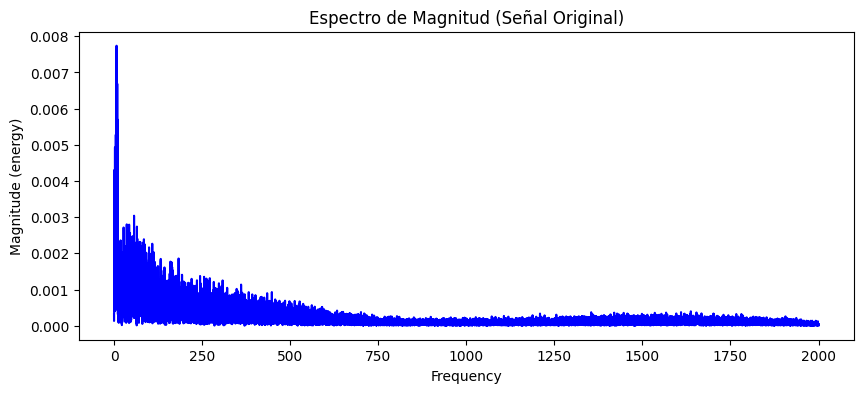

In [5]:
#Cargamos el registro y extraemos la señal y la frecuencia
record = wfdb.rdrecord('emg_healthy', pn_dir='emgdb/1.0.0')
x = record.p_signal[:, 0]  #Tomamos el primer canal de EMG
fs = record.fs             #Frecuencia de muestreo (4000 Hz)

#1. Graficar el espectro de magnitud original
plt.figure(figsize=(10, 4))
plt.magnitude_spectrum(x, Fs=fs, color='blue')
plt.title("Espectro de Magnitud (Señal Original)")
plt.show()

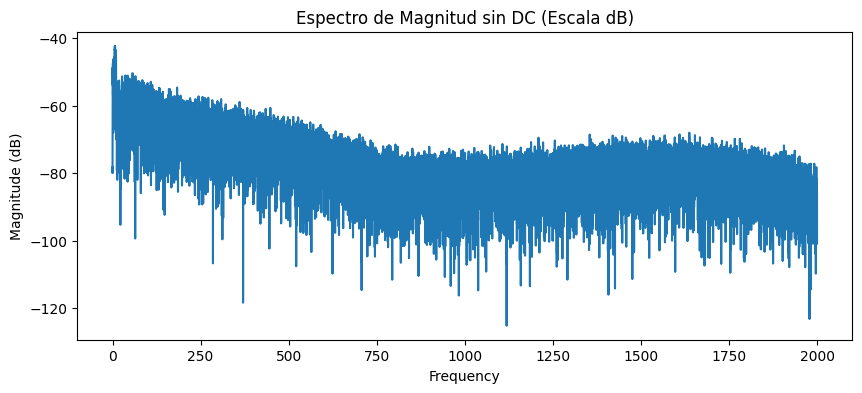

In [7]:
#2.Remover el componente DC (centrar la señal)
x_dc_removed = x - np.mean(x)

#Graficar el nuevo espectro en escala de Decibelios
plt.figure(figsize=(10, 4))
plt.magnitude_spectrum(x_dc_removed, Fs=fs, scale='dB')
plt.title("Espectro de Magnitud sin DC (Escala dB)")
plt.show()

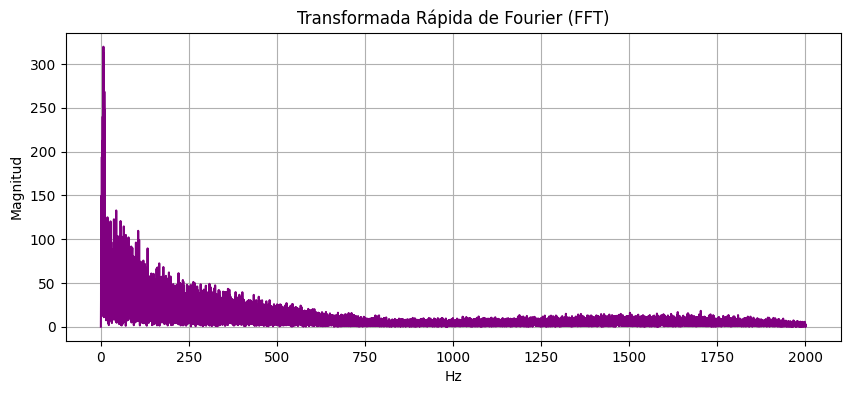

In [8]:
#3.Calcular la FFT
X = np.fft.fft(x_dc_removed)
freqs = np.fft.fftfreq(len(x_dc_removed), 1/fs)

#Tomar solo la primera mitad de los datos (frecuencias positivas)
mitad = len(x_dc_removed) // 2

plt.figure(figsize=(10, 4))
plt.plot(freqs[:mitad], np.abs(X[:mitad]), color='purple')
plt.title("Transformada Rápida de Fourier (FFT)")
plt.xlabel("Hz")
plt.ylabel("Magnitud")
plt.grid(True)
plt.show()

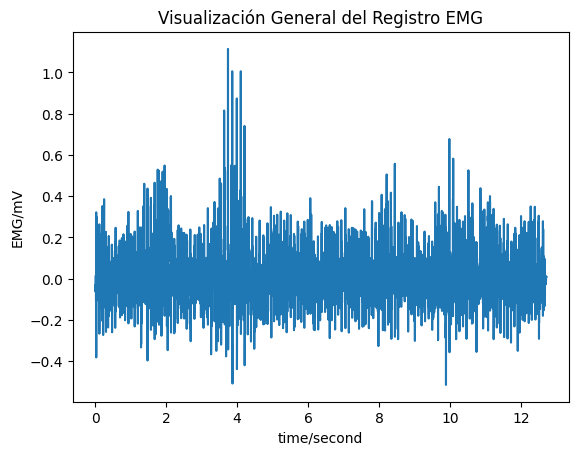

In [15]:
#Si tienes un archivo de anotaciones cargado previamente:
#annotation = wfdb.rdann('emg_healthy', 'atr', pn_dir='emgdb/1.0.0') # (Si aplica)
#Si en el repositorio de la base de datos solo ves archivos .hea y .dat, significa
#que la base de datos contiene señales "crudas" sin etiquetas de eventos médicos predefinidas.

#4.Graficar usando la herramienta nativa de wfdb
wfdb.plot_wfdb(record=record, annotation= None, title="Visualización General del Registro EMG")

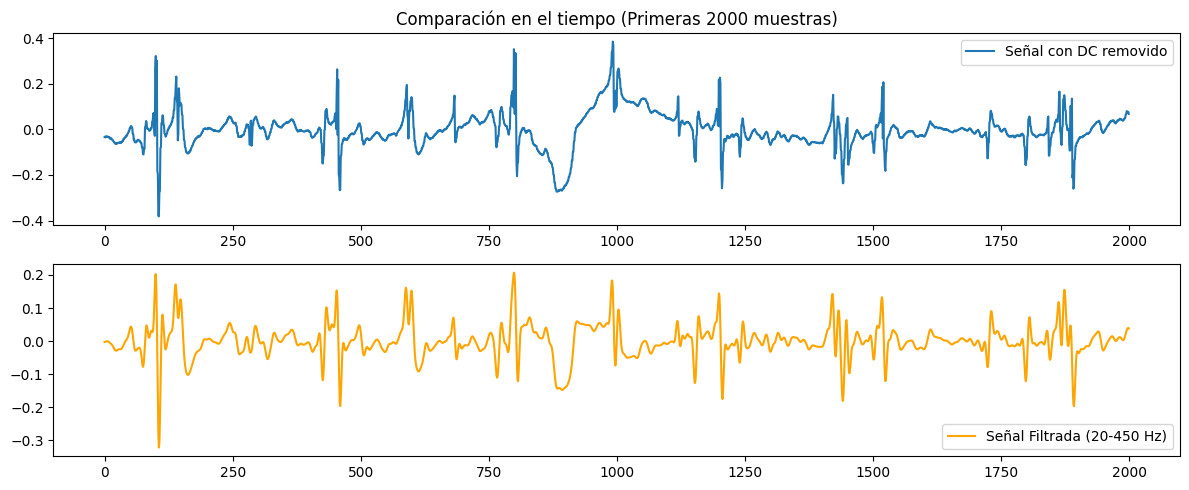

In [16]:
from scipy import signal

#1.Definir los parámetros del filtro
fs = record.fs  # 4000 Hz
lowcut = 20.0
highcut = 450.0

#2.Crear la función del filtro Butterworth
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(order, [low, high], btype='band')
    return b, a

#3Aplicar el filtro a la señal sin DC
b, a = butter_bandpass(lowcut, highcut, fs, order=4)
x_filtered = signal.filtfilt(b, a, x_dc_removed)

#4.Visualización del resultado
plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(x_dc_removed[:2000], label="Señal con DC removido")
plt.legend()
plt.title("Comparación en el tiempo (Primeras 2000 muestras)")

plt.subplot(2, 1, 2)
plt.plot(x_filtered[:2000], color='orange', label="Señal Filtrada (20-450 Hz)")
plt.legend()
plt.tight_layout()
plt.show()

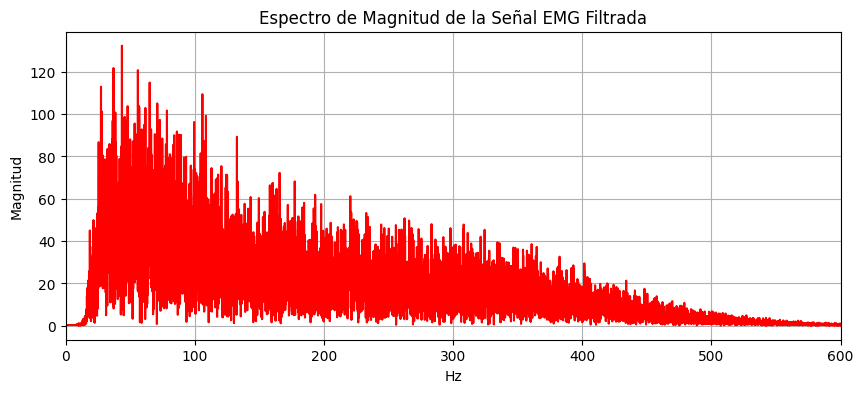

In [17]:
#Calcular FFT de la señal filtrada
X_filt = np.fft.fft(x_filtered)
freqs = np.fft.fftfreq(len(x_filtered), 1/fs)
mitad = len(x_filtered) // 2

plt.figure(figsize=(10, 4))
plt.plot(freqs[:mitad], np.abs(X_filt[:mitad]), color='red')
plt.title("Espectro de Magnitud de la Señal EMG Filtrada")
plt.xlabel("Hz")
plt.ylabel("Magnitud")
plt.xlim(0, 600) #Hacemos zoom en el rango de interés
plt.grid(True)
plt.show()